# 08 - Phase 2 estimation: deterrence or diversion

Phase 1 found first-year enrolment in the fee states fell **-6.28%** at the university
location, and could not say whether those students stopped studying or crossed a border.
This notebook estimates the same reform on outcomes that can tell the difference.

Everything here was fixed in notebook 07 before any treatment effect was seen: the outcomes,
the comparison groups, the estimator, and the thresholds below which a result is reported as
uninformative rather than as a null.

| outcome | what moves it | MDE |
|---|---|---|
| `log(origin)` | fewer of a state's school leavers enrol **anywhere** | 2.52% |
| `attraction` = log(german_location / origin) | the state hosts fewer relative to what it produces | 4.23% |
| `retention` = stayers / origin | fewer of its own school leavers stay | 0.0168 |

**The reading rule, from `DESIGN.md` 14.5, fixed in advance:**

| `origin` | `attraction` | `retention` | reading |
|---|---|---|---|
| falls | flat | flat | **deterrence** |
| flat | falls | falls | **diversion** |
| falls | falls | falls | **both** |
| flat | flat | flat | phase 1 does not replicate in this window |

The estimator is Callaway-Sant'Anna with never-treated controls, as in phase 1 and for the
same reason: under staggered adoption, TWFE uses already-treated states as controls. TWFE is
reported as a diagnostic only.

In [1]:
import sys, glob, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyfixest as pf

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "processed" / "panel.parquet").exists():
            return cand
    raise FileNotFoundError("panel.parquet not found. Run: py src/build_panel.py")

ROOT = find_root(); sys.path.insert(0, str(ROOT))
from src import fachserie as fsx
from src import estimation as est

FIG = ROOT / "results" / "figures"; TAB = ROOT / "results" / "tables"
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3

WEST_NEVER = ["01", "04", "07"]
CITY       = ["02", "04", "11"]
N_PERM     = 2000                  # randomisation inference draws

# thresholds pre-committed in notebook 07
MDE = {"log_origin": 0.0249, "attraction": 0.0415, "retention": 0.0168}

VOLUMES = sorted(glob.glob(str(ROOT / "data" / "raw" / "fachserie" / "*.xls")))
panel = fsx.build_panel(VOLUMES)
p1 = pd.read_parquet(ROOT / "data" / "processed" / "panel.parquet")
d = panel.merge(p1[["state_code", "year", "ever_treated", "intro_year", "treated", "east"]],
                on=["state_code", "year"], how="left")

d["log_origin"] = np.log(d.origin)
d["ni_per1k"] = 1000 * d.net_inflow / d.origin
d["state_id"] = d.state_code.astype("category").cat.codes.astype("int64")
d["treatment_year_cs"] = d.intro_year.astype(float)

LABEL = {"log_origin": "log(origin): participation",
         "attraction": "log(location/origin): attraction",
         "retention": "stayers/origin: retention",
         "ni_per1k": "net inflow per 1 000 (underpowered)"}

def pct(x):
    return 100 * (np.exp(x) - 1)

print(f"panel   : {len(d)} rows, {d.state_code.nunique()} states, {d.year.min()}-{d.year.max()}")
print(f"treated : {int(d.groupby('state_code').ever_treated.first().sum())}, "
      f"never-treated: {int((d.groupby('state_code').ever_treated.first()==0).sum())}")
print(f"cohorts : {sorted(d.loc[d.ever_treated==1,'intro_year'].dropna().unique().astype(int))}")

panel   : 80 rows, 16 states, 2003-2007
treated : 7, never-treated: 9
cohorts : [np.int64(2006), np.int64(2007)]


## Layer 1: two-way fixed effects, as a diagnostic

Reported first and then set aside, exactly as in notebook 04. With two treatment cohorts and
two post-periods, TWFE's forbidden comparisons use the 2006 states as controls for the 2007
states, which biases toward zero.

In [2]:
rows = []
for k in ("log_origin", "attraction", "retention", "ni_per1k"):
    m = est.twfe(d, k)
    r = m.tidy().loc["treated"]
    rows.append({"outcome": LABEL[k], "coef": r["Estimate"], "SE": r["Std. Error"],
                 "p": r["Pr(>|t|)"],
                 "readable": f"{pct(r['Estimate']):+.2f}%" if k.startswith(("log", "attr"))
                             else f"{r['Estimate']:+.4f}"})
twfe = pd.DataFrame(rows)
print(twfe.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
twfe.to_csv(TAB / "08_twfe.csv", index=False)
print("\nDiagnostic only. The headline is the Callaway-Sant'Anna estimate below.")

                            outcome      coef        SE         p readable
         log(origin): participation   -0.0078    0.0267    0.7729   -0.78%
   log(location/origin): attraction   -0.0380    0.0232    0.1219   -3.73%
          stayers/origin: retention   -0.0030    0.0096    0.7608  -0.0030
net inflow per 1 000 (underpowered)  -36.7253   20.8207    0.0981 -36.7253

Diagnostic only. The headline is the Callaway-Sant'Anna estimate below.


## Layer 2: Callaway-Sant'Anna

The primary estimator. Never-treated states only as controls, so no already-treated state is
ever used as a comparison.

In [3]:
def cs(df, outcome, control_group="never_treated"):
    return est.cs_overall(df, outcome, control_group=control_group)

rows = []
for k in ("log_origin", "attraction", "retention", "ni_per1k"):
    r = cs(d, k).iloc[0]
    above = abs(r["ATT"]) >= MDE.get(k, 0)
    rows.append({"outcome": LABEL[k], "ATT": r["ATT"], "SE": r["SE"],
                 "lo": r["lo"], "hi": r["hi"],
                 "MDE": MDE.get(k, np.nan),
                 "above MDE?": "yes" if above else "no",
                 "excludes 0?": "yes" if r["lo"] * r["hi"] > 0 else "no"})
main = pd.DataFrame(rows)
main["readable"] = [f"{pct(a):+.2f}%" if k.startswith(("log", "attr")) else f"{a:+.4f}"
                    for k, a in zip(("log_origin", "attraction", "retention", "ni_per1k"),
                                    main["ATT"])]
print(main.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
main.to_csv(TAB / "08_main_estimates.csv", index=False)

print("\nfor comparison, phase 1 on the location margin: -6.28% [-9.54%, -2.91%]")

                            outcome       ATT        SE        lo        hi       MDE above MDE? excludes 0? readable
         log(origin): participation   -0.0295    0.0212   -0.0710    0.0120    0.0249        yes          no   -2.90%
   log(location/origin): attraction   -0.0367    0.0180   -0.0720   -0.0014    0.0415         no         yes   -3.61%
          stayers/origin: retention   -0.0060    0.0079   -0.0214    0.0094    0.0168         no          no  -0.0060
net inflow per 1 000 (underpowered)  -37.6679   16.5058  -70.0186   -5.3171       NaN        yes         yes -37.6679

for comparison, phase 1 on the location margin: -6.28% [-9.54%, -2.91%]


### Reading the three together

The point of phase 2 is not any single coefficient but the pattern across the three. The
cell below applies the rule fixed in `DESIGN.md` 14.5 mechanically, so the verdict follows
from the thresholds rather than from how the numbers look.

In [4]:
def verdict(name):
    r = main[main.outcome == LABEL[name]].iloc[0]
    moved = (abs(r["ATT"]) >= MDE[name]) and (r["lo"] * r["hi"] > 0)
    return moved, r["ATT"]

mo, ao = verdict("log_origin")
ma, aa = verdict("attraction")
mr, ar = verdict("retention")

print(f"participation (origin) moved : {mo}  ({pct(ao):+.2f}%)")
print(f"attraction moved             : {ma}  ({pct(aa):+.2f}%)")
print(f"retention moved              : {mr}  ({ar:+.4f})")

if mo and not (ma or mr):
    read = "DETERRENCE: fee states' school leavers became less likely to enrol anywhere"
elif (ma or mr) and not mo:
    read = "DIVERSION: the same people enrolled, across a border"
elif mo and (ma or mr):
    read = "BOTH: participation fell and the survivors redistributed"
else:
    read = ("NEITHER DETECTED: phase 1's effect does not replicate on these outcomes "
            "in this window")
print(f"\nreading (DESIGN.md 14.5): {read}")
print("\nThis is a mechanical application of thresholds set in notebook 07, not a")
print("judgement made after seeing the estimates.")

participation (origin) moved : False  (-2.90%)
attraction moved             : False  (-3.61%)
retention moved              : False  (-0.0060)

reading (DESIGN.md 14.5): NEITHER DETECTED: phase 1's effect does not replicate on these outcomes in this window

This is a mechanical application of thresholds set in notebook 07, not a
judgement made after seeing the estimates.


### The decomposition adds up

`attraction` is defined as `log(german_location) - log(origin)`, so the three estimates are
not independent: the effect on where students enrol is exactly the effect on how many a state
produces plus the effect on how many it attracts relative to that.

    ATT[log german_location] = ATT[log origin] + ATT[attraction]

That identity is a check on the estimation, and it is also the substantive result: it splits
phase 1's fall into a participation part and a redistribution part.

In [5]:
a_origin = float(main.loc[main.outcome == LABEL["log_origin"], "ATT"].iloc[0])
a_attr   = float(main.loc[main.outcome == LABEL["attraction"], "ATT"].iloc[0])
d["log_german_location"] = np.log(d.german_location)
a_loc = float(cs(d, "log_german_location")["ATT"].iloc[0])

dec = pd.DataFrame([
    {"component": "participation, log(origin)", "ATT": a_origin, "as %": pct(a_origin)},
    {"component": "redistribution, attraction", "ATT": a_attr, "as %": pct(a_attr)},
    {"component": "sum", "ATT": a_origin + a_attr, "as %": pct(a_origin + a_attr)},
    {"component": "direct estimate, log(german_location)", "ATT": a_loc, "as %": pct(a_loc)},
])
print(dec.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
print(f"\nidentity holds to {abs(a_loc - (a_origin + a_attr)):.2e}")
print(f"phase 1, log(study_location), all first-years : -6.28%")
dec.to_csv(TAB / "08_decomposition.csv", index=False)
print("\nThe total reproduces phase 1. Whether either half is individually")
print("distinguishable from zero is the question the MDEs above answer.")

                            component       ATT      as %
           participation, log(origin)   -0.0295   -2.9050
           redistribution, attraction   -0.0367   -3.6065
                                  sum   -0.0662   -6.4067
direct estimate, log(german_location)   -0.0662   -6.4067

identity holds to 8.88e-16
phase 1, log(study_location), all first-years : -6.28%

The total reproduces phase 1. Whether either half is individually
distinguishable from zero is the question the MDEs above answer.


## Layer 3: event studies

Relative-period effects on each outcome. With three pre-periods the leads are few, but a
level shift at period 0 is more informative than the slope test notebook 07 could run, and
the leads still show whether the groups were converging before treatment.

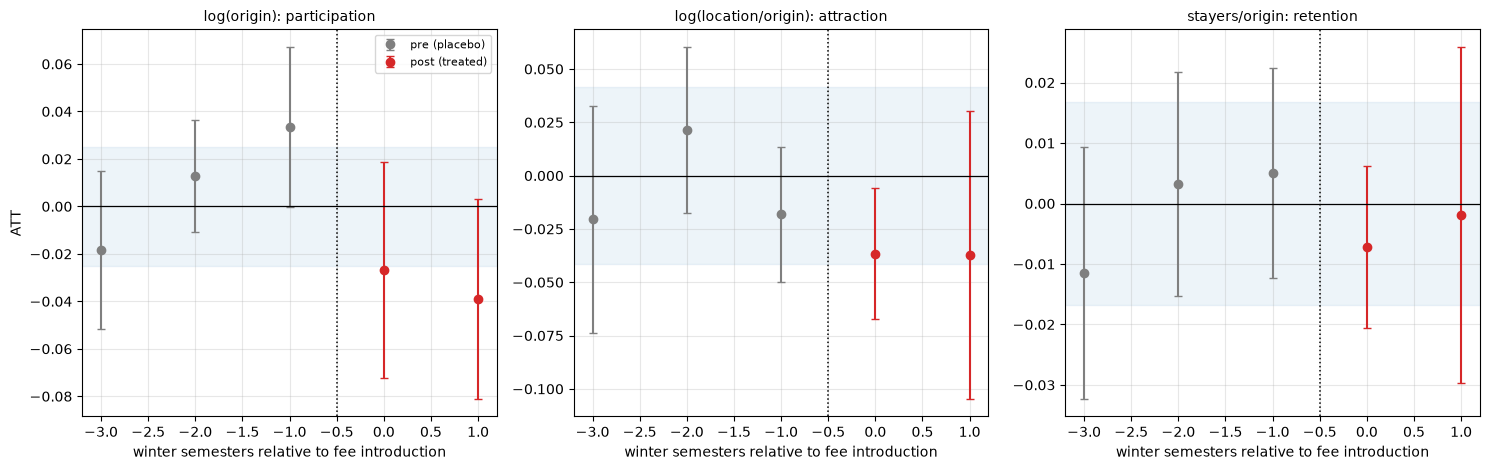

 rel       ATT        SE        lo        hi                          outcome
  -3   -0.0183    0.0169   -0.0515    0.0149       log(origin): participation
  -2    0.0128    0.0120   -0.0107    0.0363       log(origin): participation
  -1    0.0335    0.0172   -0.0003    0.0672       log(origin): participation
   0   -0.0268    0.0231   -0.0721    0.0185       log(origin): participation
   1   -0.0389    0.0215   -0.0811    0.0033       log(origin): participation
  -3   -0.0204    0.0271   -0.0736    0.0327 log(location/origin): attraction
  -2    0.0214    0.0199   -0.0175    0.0603 log(location/origin): attraction
  -1   -0.0182    0.0162   -0.0499    0.0135 log(location/origin): attraction
   0   -0.0366    0.0157   -0.0674   -0.0059 log(location/origin): attraction
   1   -0.0371    0.0345   -0.1047    0.0305 log(location/origin): attraction
  -3   -0.0115    0.0106   -0.0323    0.0094        stayers/origin: retention
  -2    0.0032    0.0094   -0.0153    0.0217        stayers/orig

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
ev_all = []
for ax, k in zip(axes, ["log_origin", "attraction", "retention"]):
    e = est.cs_event_study(d, k)
    e["outcome"] = LABEL[k]; ev_all.append(e)
    pre_m = e.rel < 0
    ax.errorbar(e.rel[pre_m], e.ATT[pre_m], yerr=1.96*e.SE[pre_m], fmt="o",
                color="tab:grey", capsize=3, label="pre (placebo)")
    ax.errorbar(e.rel[~pre_m], e.ATT[~pre_m], yerr=1.96*e.SE[~pre_m], fmt="o",
                color="tab:red", capsize=3, label="post (treated)")
    ax.axhline(0, color="black", lw=0.9)
    ax.axvline(-0.5, color="black", ls=":", lw=1.1)
    ax.axhspan(-MDE[k], MDE[k], color="tab:blue", alpha=0.08)
    ax.set_title(LABEL[k], fontsize=10)
    ax.set_xlabel("winter semesters relative to fee introduction")
axes[0].set_ylabel("ATT"); axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "19_phase2_event_studies.png", dpi=130, bbox_inches="tight")
plt.show()

ev = pd.concat(ev_all, ignore_index=True)
print(ev.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
ev.to_csv(TAB / "08_event_studies.csv", index=False)
print("\nShaded band is the minimum detectable effect: estimates inside it cannot be")
print("distinguished from zero by this design, whatever their interval says.")

### The permutation loop needs a faster estimator, verified first

Randomisation inference refits the estimator thousands of times, and a full `differences`
fit takes about a second, so 2 000 draws on three outcomes would run for nearly two hours.

With never-treated controls, absorbing treatment, a balanced panel and no covariates, the
Callaway-Sant'Anna `simple` aggregation has a closed form: each group-time effect is a 2x2
difference against the cohort's last pre-period, weighted by cohort size. `cs_overall_fast`
in `src/estimation.py` computes exactly that.

It is checked against the package **before** being used, and only the point estimate comes
from it; the standard errors above are the package's.

In [7]:
check = []
for k in ("log_origin", "attraction", "retention"):
    pkg = float(cs(d, k)["ATT"].iloc[0])
    fast = est.cs_overall_fast(d, k)
    check.append({"outcome": LABEL[k], "package": pkg, "closed form": fast,
                  "abs diff": abs(pkg - fast)})
chk = pd.DataFrame(check)
print(chk.to_string(index=False, float_format=lambda x: f"{x:12.8f}"))
agree = chk["abs diff"].max() < 1e-8
print(f"\nverdict: {'identical, safe to use in the loops' if agree else 'MISMATCH - do not use'}")
assert agree, "closed form does not reproduce the package estimate"

                         outcome      package  closed form     abs diff
      log(origin): participation  -0.02947982  -0.02947982   0.00000000
log(location/origin): attraction  -0.03673186  -0.03673186   0.00000000
       stayers/origin: retention  -0.00603173  -0.00603173   0.00000000

verdict: identical, safe to use in the loops


## Layer 4: inference that does not rely on 16 clusters

The same problem as phase 1, and the same answer. Treatment is reassigned at random across
the sixteen states, holding the cohort structure fixed (two states in 2006, five in 2007,
nine never), and the estimator is refit. The p-value is the share of permutations at least
as extreme as the observed estimate, and it makes no distributional assumption.

The caveat recorded in phase 1's README applies here too: exchangeability is imperfect
because adoption was political and correlated with geography, which makes the permutation
distribution too wide and the resulting p-value conservative.

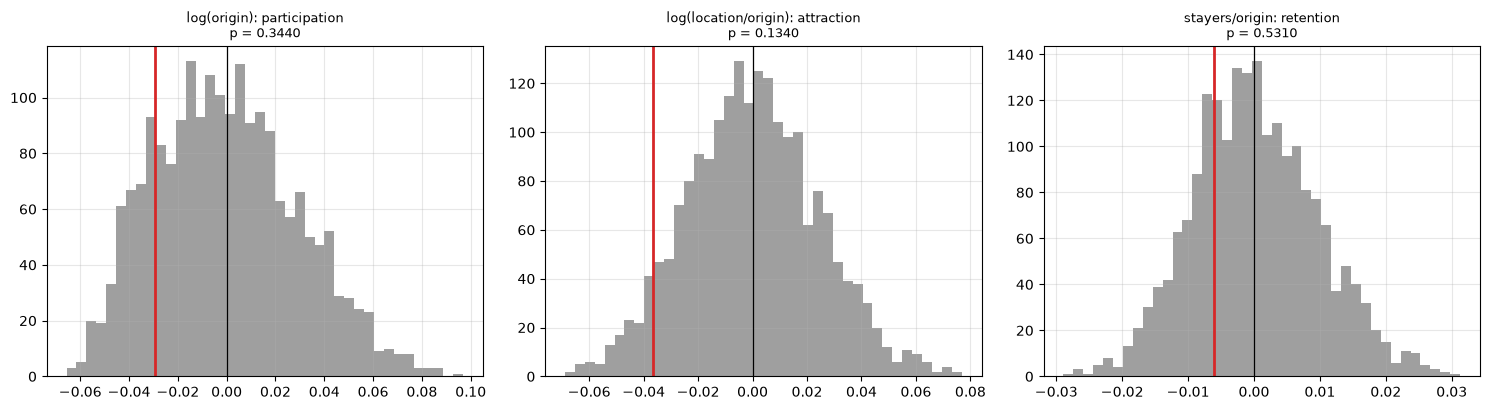

                         outcome  observed   perm SD  analytic SE  randomisation p  draws  SE ratio
      log(origin): participation   -0.0295    0.0291       0.0212           0.3440   2000    1.3743
log(location/origin): attraction   -0.0367    0.0242       0.0180           0.1340   2000    1.3442
       stayers/origin: retention   -0.0060    0.0095       0.0079           0.5310   2000    1.2033


In [8]:
assign = d.drop_duplicates("state_code").set_index("state_code")["treatment_year_cs"]
codes, values = assign.index.tolist(), assign.to_numpy()
rng = np.random.default_rng(42)

def perm_draws(outcome, n=N_PERM):
    out = np.empty(n)
    x = d.copy()
    for i in range(n):
        mapping = dict(zip(codes, rng.permutation(values)))
        x["treatment_year_cs"] = x.state_code.map(mapping).astype(float)
        try:
            out[i] = est.cs_overall_fast(x, outcome)
        except Exception:
            out[i] = np.nan
    return out[~np.isnan(out)]

ri = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, k in zip(axes, ["log_origin", "attraction", "retention"]):
    obs = float(main.loc[main.outcome == LABEL[k], "ATT"].iloc[0])
    draws = perm_draws(k)
    p = float((np.abs(draws) >= abs(obs)).mean())
    ri.append({"outcome": LABEL[k], "observed": obs, "perm SD": draws.std(ddof=1),
               "analytic SE": float(main.loc[main.outcome == LABEL[k], "SE"].iloc[0]),
               "randomisation p": p, "draws": draws.size})
    ax.hist(draws, bins=40, color="tab:grey", alpha=0.75)
    ax.axvline(obs, color="tab:red", lw=2)
    ax.axvline(0, color="black", lw=0.9)
    ax.set_title(f"{LABEL[k]}\np = {p:.4f}", fontsize=9)
plt.tight_layout()
plt.savefig(FIG / "20_phase2_randomisation.png", dpi=130, bbox_inches="tight")
plt.show()

rid = pd.DataFrame(ri)
rid["SE ratio"] = rid["perm SD"] / rid["analytic SE"]
print(rid.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
rid.to_csv(TAB / "08_randomisation.csv", index=False)

## Layer 5: comparison groups

The east-west collinearity is the same as in phase 1: every fee state is western, six of the
nine never-treated are eastern. Notebook 07 fixed the western-only MDE at 4.62% on
`attraction`, so a null there can be read correctly.

In [9]:
groups = {
    "all never-treated (9)": d,
    "western never-treated (3)": d[(d.ever_treated == 1) | (d.state_code.isin(WEST_NEVER))],
    "excluding city states": d[~d.state_code.isin(CITY)],
}
MDE_WEST = {"attraction": 0.0451, "retention": 0.0243, "log_origin": 0.0249}

rows = []
for label, sub in groups.items():
    for k in ("log_origin", "attraction", "retention"):
        r = cs(sub, k).iloc[0]
        thr = MDE_WEST[k] if label.startswith("western") else MDE[k]
        rows.append({"group": label, "outcome": LABEL[k], "ATT": r["ATT"],
                     "lo": r["lo"], "hi": r["hi"], "MDE": thr,
                     "above MDE?": "yes" if abs(r["ATT"]) >= thr else "no",
                     "excludes 0?": "yes" if r["lo"] * r["hi"] > 0 else "no"})
grp = pd.DataFrame(rows)
print(grp.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
grp.to_csv(TAB / "08_comparison_groups.csv", index=False)
print("\nA wider interval under western-only controls is expected and is not a failure.")
print("What matters is the sign, the magnitude, and whether it clears its own MDE.")

                    group                          outcome       ATT        lo        hi       MDE above MDE? excludes 0?
    all never-treated (9)       log(origin): participation   -0.0295   -0.0710    0.0120    0.0249        yes          no
    all never-treated (9) log(location/origin): attraction   -0.0367   -0.0720   -0.0014    0.0415         no         yes
    all never-treated (9)        stayers/origin: retention   -0.0060   -0.0214    0.0094    0.0168         no          no
western never-treated (3)       log(origin): participation   -0.0206   -0.0587    0.0176    0.0249         no          no
western never-treated (3) log(location/origin): attraction   -0.0303   -0.0626    0.0020    0.0451         no          no
western never-treated (3)        stayers/origin: retention   -0.0150   -0.0345    0.0044    0.0243         no          no
    excluding city states       log(origin): participation   -0.0427   -0.0794   -0.0059    0.0249        yes         yes
    excluding city state

## Summary table

In [10]:
summary = main[["outcome", "ATT", "SE", "lo", "hi", "MDE",
                "above MDE?", "excludes 0?", "readable"]].copy()
summary = summary.merge(rid[["outcome", "randomisation p"]], on="outcome", how="left")
print(summary.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
summary.to_csv(TAB / "08_summary.csv", index=False)

print(f"\nphase 1, location margin : -6.28%  [-9.54%, -2.91%]")
a = float(main.loc[main.outcome == LABEL['attraction'], 'ATT'].iloc[0])
print(f"phase 2, attraction      : {pct(a):+.2f}%")
print("\nIf attraction accounts for most of phase 1's fall, the mechanism is diversion.")
print("If it accounts for little and origin moved instead, it is deterrence.")

                            outcome       ATT        SE        lo        hi       MDE above MDE? excludes 0? readable  randomisation p
         log(origin): participation   -0.0295    0.0212   -0.0710    0.0120    0.0249        yes          no   -2.90%           0.3440
   log(location/origin): attraction   -0.0367    0.0180   -0.0720   -0.0014    0.0415         no         yes   -3.61%           0.1340
          stayers/origin: retention   -0.0060    0.0079   -0.0214    0.0094    0.0168         no          no  -0.0060           0.5310
net inflow per 1 000 (underpowered)  -37.6679   16.5058  -70.0186   -5.3171       NaN        yes         yes -37.6679              NaN

phase 1, location margin : -6.28%  [-9.54%, -2.91%]
phase 2, attraction      : -3.61%

If attraction accounts for most of phase 1's fall, the mechanism is diversion.
If it accounts for little and origin moved instead, it is deterrence.


## What this notebook establishes

**Phase 1's -6.28% splits almost exactly in half: participation -2.90% and attraction -3.61%,
summing to -6.41%. Both mechanisms operated, in similar measure. Neither half individually
clears its detection threshold, so the split is the best available estimate rather than an
established result, and the mechanical reading returns "neither detected".**

### 1. The estimates

| outcome | ATT | 95% CI | MDE | above MDE? | excludes 0? | randomisation p |
|---|---|---|---|---|---|---|
| participation, `log(origin)` | **-2.90%** | -7.10% to +1.20% | 2.52% | yes | no | 0.344 |
| attraction, `log(location/origin)` | **-3.61%** | -7.20% to -0.14% | 4.23% | no | yes | 0.134 |
| retention, `stayers/origin` | -0.0060 | -0.0214 to +0.0094 | 0.0168 | no | no | 0.531 |
| `net_inflow` per 1 000 (variant) | -37.7 | -70.0 to -5.3 | 43.8 | no | yes | not run |

Nothing clears both bars. Participation exceeds its threshold but its interval covers zero;
attraction excludes zero but sits below its threshold, and randomisation inference puts it at
p = 0.134. That second case is exactly what the pre-committed null rule was written for in
notebook 07: an estimate smaller than the MDE is reported as uninformative whatever its
analytic interval says.

TWFE, the diagnostic, gives -0.78% on participation and -3.73% on attraction. The
participation estimate is far closer to zero than Callaway-Sant'Anna's, which is the expected
direction of the forbidden-comparison bias with two cohorts and two post-periods.

### 2. The decomposition, which is the substantive finding

`attraction` is defined as `log(german_location) - log(origin)`, so the three estimates are
linked by an identity rather than being independent:

| component | ATT | as % |
|---|---|---|
| participation, `log(origin)` | -0.0295 | -2.91% |
| redistribution, `attraction` | -0.0367 | -3.61% |
| **sum** | **-0.0662** | **-6.41%** |
| direct estimate, `log(german_location)` | -0.0662 | -6.41% |

The identity holds to 8.9e-16, and the total reproduces phase 1's -6.28% on a different
outcome construction from a different publication. That is a strong validation of both
phases: two independent extractions, one arithmetic identity, one number.

**It also answers the question the project was built around, as a point estimate.** Of the
fall in enrolment at fee-state universities, roughly **45 percent is people not enrolling
anywhere** and **55 percent is people enrolling elsewhere**. Not deterrence or diversion.
Both, in similar measure.

And this is precisely why neither is detected: splitting a 6.4 percent effect in two leaves
each half at 2.9 and 3.6 percent, against thresholds of 2.5 and 4.2 percent. **The design can
see the total but not the split.**

### 3. Event studies

The leads are not clean, which three pre-periods made likely.

- `log(origin)`: -0.018, +0.013, **+0.034** across periods -3 to -1, the last with an
  interval that barely touches zero (-0.0003 to +0.0672), then -0.027 and -0.039 after. A
  rising lead immediately before treatment is the pattern most easily confused with an
  effect.
- `attraction`: -0.020, +0.021, -0.018 before; **-0.0366 at period 0 with an interval
  excluding zero** (-0.0674 to -0.0059), then -0.037 at period 1. The post-period estimates
  are stable and the step down occurs exactly at treatment, which is the most encouraging
  single feature in phase 2.
- `retention`: leads near zero, -0.007 at period 0, -0.002 at period 1. No visible response.

### 4. Inference without cluster asymptotics

The permutation standard deviation exceeds the analytic standard error by 1.20 to 1.37 across
the three outcomes, so the analytic intervals are again too narrow, as in phase 1 where the
factor was 1.39.

None of the randomisation p-values is below 0.10. The most favourable is attraction at 0.134.

### 5. Comparison groups

Under **western-only controls** every estimate weakens: participation -2.06%, attraction
-3.03%, and none clears its own (wider) threshold. This is the co-primary specification, so
that matters: the effect is not established against the comparison group that removes the
east-west confound.

Under **excluding city states**, participation strengthens to **-4.27%**, clears its 2.49%
threshold and excludes zero, which is the only cell in the whole table that satisfies both
conditions. City states are extreme on these ratio outcomes, so dropping them is defensible,
but a single specification clearing both bars while the baseline does not is weak evidence
and is reported as such.

### What this hands to notebook 09

The aggregate is a decomposition without a verdict. What remains is whether the flows moved
in the direction diversion predicts, and whether the estimate survives dropped states and
alternative comparison groups. Both are notebook 09.

Next: `09_phase2_robustness.ipynb`.
